# **MAIN MODELING PIPELINE**

## **IMPORTS**

In [1]:
#imports

import pandas as pd
import numpy as np 

#for importing the preprocessor done in the preprocessing folder
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from preprocessing.preprocessor import preprocessorLOEE_OH,preprocessorClassic,preprocessorLOEEALL,preprocessorLOEE_oh_TE_te, preprocessorLOEE_te_TE_oh,preprocessorTEALL, orig_onehot_enc_cols, orig_target_enc_cols, original_preprocessorLOEEALL, onehot_enc_cols, target_enc_cols


from sklearn.base import clone

# Optuna
import optuna


from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

from sklearn.pipeline import Pipeline
from imblearn.pipeline import make_pipeline as imb_make_pipeline

from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, make_scorer, cohen_kappa_score


from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, make_scorer, cohen_kappa_score

# Model imports
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import RandomOverSampler

from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression



c:\Users\iker\anaconda3\envs\machine_learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **DATA PREPARATION**

### Dataset splitting

In [2]:
# DON'T EXECUTE AGAIN, THE SPLIT IS ALREADY DONE AND CAN BE LOADED USING ITS SPECIFIC FILES
'''
df= pd.read_parquet("../data/cleaned/cleaned_df_final.parquet")
#print(df.columns.tolist())

#1. Stratified split 
X = df.drop("AdoptionSpeed", axis=1)
y = df["AdoptionSpeed"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

#We store the partiions of the final df
X_train.to_parquet("../data/cleaned/X_train.parquet", index=False)
X_test.to_parquet("../data/cleaned/X_test.parquet", index=False)
y_train.to_frame().to_parquet("../data/cleaned/y_train.parquet", index=False)
y_test.to_frame().to_parquet("../data/cleaned/y_test.parquet", index=False)
'''

'\ndf= pd.read_parquet("../data/cleaned/cleaned_df_final.parquet")\n#print(df.columns.tolist())\n\n#1. Stratified split \nX = df.drop("AdoptionSpeed", axis=1)\ny = df["AdoptionSpeed"]\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)\n\nprint(X_train.shape)\nprint(y_train.shape)\nprint(X_test.shape)\nprint(y_test.shape)\n\n#We store the partiions of the final df\nX_train.to_parquet("../data/cleaned/X_train.parquet", index=False)\nX_test.to_parquet("../data/cleaned/X_test.parquet", index=False)\ny_train.to_frame().to_parquet("../data/cleaned/y_train.parquet", index=False)\ny_test.to_frame().to_parquet("../data/cleaned/y_test.parquet", index=False)\n'

### Dataset loading

In [3]:
# We read the partitions
X_train = pd.read_parquet("../data/cleaned/X_train.parquet")
X_test = pd.read_parquet("../data/cleaned/X_test.parquet")
y_train = pd.read_parquet("../data/cleaned/y_train.parquet").squeeze()
y_test = pd.read_parquet("../data/cleaned/y_test.parquet").squeeze()

# Check that all has been loaded correctly
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# We define the categorical columns
categorical_cols = ['Type', 'Gender', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'RescuerID', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength','Breed1', 'Breed2', 'State']


(10045, 32)
(10045,)
(4948, 32)
(4948,)


## **BASELINE MODELS WITH TRAINING DATA**

### Scoring setup for all models

In [4]:
qwk = make_scorer(cohen_kappa_score, weights="quadratic")
used_scores = {
            "f1_macro": "f1_macro",
            "QWK": qwk
        }



### Random Forest baseline for preprocessing

In [5]:



#2. Baseline model (RandomForestClassifier with default hyperparameters)
baseline_clf = RandomForestClassifier(random_state=42)

pipe0 = Pipeline (steps=[("preprocessorClassic",preprocessorClassic), ("rf",baseline_clf)])
pipe1 = Pipeline (steps=[("preprocessorLOEEALL",preprocessorLOEEALL), ("rf",baseline_clf)])
pipe2 = Pipeline (steps=[("preprocessorLOEE_OH",preprocessorLOEE_OH), ("rf",baseline_clf)])
pipe3 = Pipeline (steps=[("preprocessorLOEE_oh_TE_te",preprocessorLOEE_oh_TE_te), ("rf",baseline_clf)])
pipe4 = Pipeline (steps=[("preprocessorLOEE_te_TE_oh",preprocessorLOEE_te_TE_oh), ("rf",baseline_clf)])
pipe5 = Pipeline (steps=[("preprocessorTEALL",preprocessorTEALL), ("rf",baseline_clf)])

pipelines = [pipe0,pipe1,pipe2,pipe3,pipe4,pipe5]


skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

i = 0
for pipe in pipelines: 
    scores = cross_validate(pipe, X_train, y_train, cv=skf, scoring=used_scores, return_train_score=True) 
    print(f"\nPipe{i}...............")
    print(f"TRAIN: F1-macro: {round(np.mean(scores['train_f1_macro']),4)}, QWK mean: {round(np.mean(scores['train_QWK']),4)}, QWK std: {round(np.std(scores['train_QWK']),4)}")
    print(f"TEST: F1-macro: {round(np.mean(scores['test_f1_macro']),4)}, QWK mean: {round(np.mean(scores['test_QWK']),4)}, QWK std: {round(np.std(scores['test_QWK']),4)}")
    i = i+1

"""

Pipe0...............
TRAIN: F1-macro: 1.0, QWK mean: 1.0, QWK std: 0.0
TEST: F1-macro: 0.3256, QWK mean: 0.3919, QWK std: 0.0149

Pipe1............... THE PREPROCESSOR ONLY USING LEAVE ONE OUT ENCODING FOR ALL CATEGORICAL COLUMNS ACHIEVES THE BEST RESULTS AVOIDING HUGE OVERFITTING AND PROVIDING A GOOD QWK SCORE FOR THE BASELINE MODEL
.................... SO WE WILL BE USING THIS PREPROCESSOR FOR THE REST OF THE PROJECT
TRAIN: F1-macro: 0.4709, QWK mean: 0.5879, QWK std: 0.0046
TEST: F1-macro: 0.3114, QWK mean: 0.3883, QWK std: 0.015

Pipe2...............
TRAIN: F1-macro: 0.9238, QWK mean: 0.9269, QWK std: 0.0033
TEST: F1-macro: 0.3217, QWK mean: 0.3913, QWK std: 0.0159

Pipe3...............
TRAIN: F1-macro: 0.6853, QWK mean: 0.8278, QWK std: 0.0048
TEST: F1-macro: 0.2944, QWK mean: 0.3758, QWK std: 0.0076

Pipe4...............
TRAIN: F1-macro: 0.8851, QWK mean: 0.8914, QWK std: 0.0056
TEST: F1-macro: 0.3246, QWK mean: 0.3862, QWK std: 0.0138

Pipe5...............
TRAIN: F1-macro: 1.0, QWK mean: 1.0, QWK std: 0.0
TEST: F1-macro: 0.321, QWK mean: 0.3878, QWK std: 0.0092


"""


Pipe0...............
TRAIN: F1-macro: 1.0, QWK mean: 1.0, QWK std: 0.0
TEST: F1-macro: 0.3256, QWK mean: 0.3919, QWK std: 0.0149

Pipe1...............
TRAIN: F1-macro: 0.4709, QWK mean: 0.5879, QWK std: 0.0046
TEST: F1-macro: 0.3114, QWK mean: 0.3883, QWK std: 0.015

Pipe2...............
TRAIN: F1-macro: 0.9238, QWK mean: 0.9269, QWK std: 0.0033
TEST: F1-macro: 0.3217, QWK mean: 0.3913, QWK std: 0.0159

Pipe3...............
TRAIN: F1-macro: 0.6853, QWK mean: 0.8278, QWK std: 0.0048
TEST: F1-macro: 0.2944, QWK mean: 0.3758, QWK std: 0.0076

Pipe4...............
TRAIN: F1-macro: 0.8851, QWK mean: 0.8914, QWK std: 0.0056
TEST: F1-macro: 0.3246, QWK mean: 0.3862, QWK std: 0.0138

Pipe5...............
TRAIN: F1-macro: 1.0, QWK mean: 1.0, QWK std: 0.0
TEST: F1-macro: 0.321, QWK mean: 0.3878, QWK std: 0.0092


'\n\nPipe0...............\nTRAIN: F1-macro: 1.0, QWK mean: 1.0, QWK std: 0.0\nTEST: F1-macro: 0.3256, QWK mean: 0.3919, QWK std: 0.0149\n\nPipe1............... THE PREPROCESSOR ONLY USING LEAVE ONE OUT ENCODING FOR ALL CATEGORICAL COLUMNS ACHIEVES THE BEST RESULTS AVOIDING HUGE OVERFITTING AND PROVIDING A GOOD QWK SCORE FOR THE BASELINE MODEL\n.................... SO WE WILL BE USING THIS PREPROCESSOR FOR THE REST OF THE PROJECT\nTRAIN: F1-macro: 0.4709, QWK mean: 0.5879, QWK std: 0.0046\nTEST: F1-macro: 0.3114, QWK mean: 0.3883, QWK std: 0.015\n\nPipe2...............\nTRAIN: F1-macro: 0.9238, QWK mean: 0.9269, QWK std: 0.0033\nTEST: F1-macro: 0.3217, QWK mean: 0.3913, QWK std: 0.0159\n\nPipe3...............\nTRAIN: F1-macro: 0.6853, QWK mean: 0.8278, QWK std: 0.0048\nTEST: F1-macro: 0.2944, QWK mean: 0.3758, QWK std: 0.0076\n\nPipe4...............\nTRAIN: F1-macro: 0.8851, QWK mean: 0.8914, QWK std: 0.0056\nTEST: F1-macro: 0.3246, QWK mean: 0.3862, QWK std: 0.0138\n\nPipe5............

### Dummy baseline (stratified)

In [6]:
#2. Baseline model (RandomForestClassifier with default hyperparameters)
baseline_clf = DummyClassifier(random_state=42,strategy="stratified")

pipe = Pipeline (steps=[("preprocessor",preprocessorLOEEALL), ("rf",baseline_clf)])

skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
scores = cross_validate(pipe, X_train, y_train, cv=skf, scoring=used_scores, return_train_score=True) 

print(f"TRAIN: F1-macro: {round(np.mean(scores['train_f1_macro']),4)}, QWK mean: {round(np.mean(scores['train_QWK']),4)}, QWK std: {round(np.std(scores['train_QWK']),4)}")
print(f"TEST: F1-macro: {round(np.mean(scores['test_f1_macro']),4)}, QWK mean: {round(np.mean(scores['test_QWK']),4)}, QWK std: {round(np.std(scores['test_QWK']),4)}")
"""
TRAIN: F1-macro: 0.1991, QWK mean: -0.0052, QWK std: 0.0086
TEST: F1-macro: 0.2018, QWK mean: -0.0049, QWK std: 0.0236
"""

TRAIN: F1-macro: 0.1991, QWK mean: -0.0052, QWK std: 0.0086
TEST: F1-macro: 0.2018, QWK mean: -0.0049, QWK std: 0.0236


'\nTRAIN: F1-macro: 0.1991, QWK mean: -0.0052, QWK std: 0.0086\nTEST: F1-macro: 0.2018, QWK mean: -0.0049, QWK std: 0.0236\n'

### Dummy baseline (most frequent)

In [7]:
#2. Baseline model (RandomForestClassifier with default hyperparameters)
baseline_clf = DummyClassifier(random_state=42, strategy="most_frequent")

pipe = Pipeline (steps=[("preprocessor",preprocessorLOEEALL), ("rf",baseline_clf)])

skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
scores = cross_validate(pipe, X_train, y_train, cv=skf, scoring=used_scores, return_train_score=True) 

print(f"TRAIN: F1-macro: {round(np.mean(scores['train_f1_macro']),4)}, QWK mean: {round(np.mean(scores['train_QWK']),4)}, QWK std: {round(np.std(scores['train_QWK']),4)}")
print(f"TEST: F1-macro: {round(np.mean(scores['test_f1_macro']),4)}, QWK mean: {round(np.mean(scores['test_QWK']),4)}, QWK std: {round(np.std(scores['test_QWK']),4)}")
"""
TRAIN: F1-macro: 0.0875, QWK mean: 0.0, QWK std: 0.0
TEST: F1-macro: 0.0875, QWK mean: 0.0, QWK std: 0.0
"""

TRAIN: F1-macro: 0.0875, QWK mean: 0.0, QWK std: 0.0
TEST: F1-macro: 0.0875, QWK mean: 0.0, QWK std: 0.0


'\nTRAIN: F1-macro: 0.0875, QWK mean: 0.0, QWK std: 0.0\nTEST: F1-macro: 0.0875, QWK mean: 0.0, QWK std: 0.0\n'

### Original CSV baseline (without JSON features)

In [8]:
original_df = pd.read_csv("../data/data.csv")

#print(original_df.columns.tolist())

In [9]:
print(f"Shape: {original_df.shape}")
print(f"NA Values per columns {original_df.isna().sum()}")

#we delete rows with NA for this quick baseline model with original data 

original_df = original_df.dropna(axis=0)

print(f"Shape: {original_df.shape}")
print(f"NA Values per columns {original_df.isna().sum()}")


#We also delete the animal names, description, PetId
original_df.drop(columns=["Name"],inplace=True)
original_df.drop(columns=["Description"],inplace=True)
original_df.drop(columns=["PetID"],inplace=True)


#We convert the categorical variable to string so that the preprocessor works properly

all_categorical = orig_onehot_enc_cols + orig_target_enc_cols
original_df[all_categorical] = original_df[all_categorical].astype(str)


print(original_df.columns.tolist())




#Data split
X = original_df.drop("AdoptionSpeed", axis=1)
y = original_df["AdoptionSpeed"]
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)





Shape: (14993, 24)
NA Values per columns Type                0
Name             1265
Age                 0
Breed1              0
Breed2              0
Gender              0
Color1              0
Color2              0
Color3              0
MaturitySize        0
FurLength           0
Vaccinated          0
Dewormed            0
Sterilized          0
Health              0
Quantity            0
Fee                 0
State               0
RescuerID           0
VideoAmt            0
Description        13
PetID               0
PhotoAmt            0
AdoptionSpeed       0
dtype: int64
Shape: (13716, 24)
NA Values per columns Type             0
Name             0
Age              0
Breed1           0
Breed2           0
Gender           0
Color1           0
Color2           0
Color3           0
MaturitySize     0
FurLength        0
Vaccinated       0
Dewormed         0
Sterilized       0
Health           0
Quantity         0
Fee              0
State            0
RescuerID        0
VideoAmt        

In [10]:

baseline_clf = RandomForestClassifier(random_state=42, class_weight="balanced")

pipe = Pipeline (steps=[("preprocessor",original_preprocessorLOEEALL), ("rf",baseline_clf)])

skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
scores = cross_validate(pipe, X_train_orig, y_train_orig, cv=skf, scoring=used_scores, return_train_score=True) 

print(f"TRAIN: F1-macro: {round(np.mean(scores['train_f1_macro']),4)}, QWK mean: {round(np.mean(scores['train_QWK']),4)}, QWK std: {round(np.std(scores['train_QWK']),4)}")
print(f"TEST: F1-macro: {round(np.mean(scores['test_f1_macro']),4)}, QWK mean: {round(np.mean(scores['test_QWK']),4)}, QWK std: {round(np.std(scores['test_QWK']),4)}")

"""
TRAIN: F1-macro: 0.3864, QWK mean: 0.507, QWK std: 0.0163
TEST: F1-macro: 0.3051, QWK mean: 0.3625, QWK std: 0.0124
"""



TRAIN: F1-macro: 0.3864, QWK mean: 0.507, QWK std: 0.0163
TEST: F1-macro: 0.3051, QWK mean: 0.3625, QWK std: 0.0124


'\nTRAIN: F1-macro: 0.3864, QWK mean: 0.507, QWK std: 0.0163\nTEST: F1-macro: 0.3051, QWK mean: 0.3625, QWK std: 0.0124\n'

## **FINAL BASELINE (ON TEST SET)**

In [11]:
# Baseline model (RandomForestClassifier with default hyperparameters)
baseline_clf = RandomForestClassifier(random_state=42)

pipe = Pipeline (steps=[("preprocessorLOEEALL",preprocessorLOEEALL), ("rf",baseline_clf)])


pipe.fit(X_train, y_train)


# Predictions
train_preds = pipe.predict(X_train)
test_preds = pipe.predict(X_test)

# Train Score
train_f1 = f1_score(y_train, train_preds, average='macro')
train_qwk = cohen_kappa_score(y_train, train_preds, weights='quadratic')

# Final Test Score
test_f1 = f1_score(y_test, test_preds, average='macro')
test_qwk = cohen_kappa_score(y_test, test_preds, weights='quadratic')

print(f"FINAL RESULTS WITH BASELINE RF DEFAULT MODEL:")
print(f"TRAIN -> F1: {round(train_f1, 4)} | QWK: {round(train_qwk, 4)}")
print(f"TEST  -> F1: {round(test_f1, 4)}  | QWK: {round(test_qwk, 4)}")

"""

FINAL RESULTS WITH BASELINE RF DEFAULT MODEL: AS WE CAN SEE THE TRAIN-TEST DIFFERENCE IN QWK MANTAINS NEARLY THE SAME AS IN THE VALIDATION SCORE
TRAIN -> F1: 0.4633 | QWK: 0.5876
TEST  -> F1: 0.3011  | QWK: 0.3778

"""

FINAL RESULTS WITH BASELINE RF DEFAULT MODEL:
TRAIN -> F1: 0.4633 | QWK: 0.5876
TEST  -> F1: 0.2916  | QWK: 0.3601


'\n\nFINAL RESULTS WITH BASELINE RF DEFAULT MODEL: AS WE CAN SEE THE TRAIN-TEST DIFFERENCE IN QWK MANTAINS NEARLY THE SAME AS IN THE VALIDATION SCORE\nTRAIN -> F1: 0.4633 | QWK: 0.5876\nTEST  -> F1: 0.3011  | QWK: 0.3778\n\n'

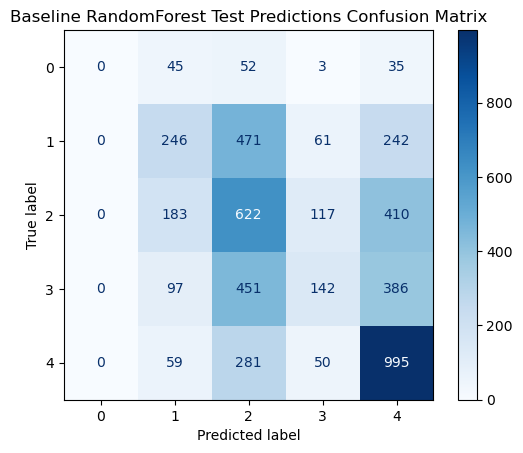

In [12]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    test_preds, 
    cmap='Blues', 
)

plt.title("Baseline RandomForest Test Predictions Confusion Matrix")

plt.savefig('../images/4_part/Baseline_RandomForest_Test_Predictions_Confusion_Matrix.png', bbox_inches='tight')

plt.show()


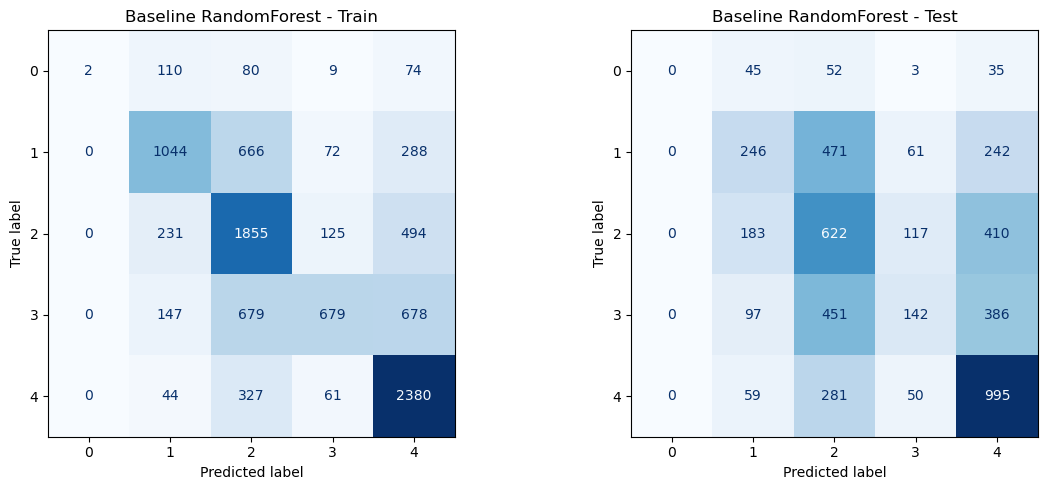

In [13]:
# Confusion matrix train vs test (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    train_preds,
    cmap='Blues',
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Baseline RandomForest - Train")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds,
    cmap='Blues',
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Baseline RandomForest - Test")

plt.tight_layout()
plt.show()

## **FINAL MODELS (ON TEST SET)**

### **Individual models**

#### Load optuna studies

In [14]:
# We load Optuna studies from the hyperparameter_tuning folder.
def load_study_safe(db_filename, preferred_name=None):
    db_path = os.path.abspath(os.path.join("..", "hyperparameter_tuning", "optuna_studies", db_filename))
    normalized_db_path = db_path.replace("\\", "/")
    storage_uri = f"sqlite:///{normalized_db_path}"

    summaries = optuna.study.get_all_study_summaries(storage=storage_uri)
    if not summaries:
        raise ValueError(f"No studies found in {storage_uri}")

    available = [s.study_name for s in summaries]

    if preferred_name and preferred_name in available:
        chosen = preferred_name
    else:
        chosen = available[-1]
        print(f"Preferred study '{preferred_name}' not found in {db_filename}. Using '{chosen}'.")

    print(f"Loaded {chosen} from {db_filename}")
    return optuna.load_study(study_name=chosen, storage=storage_uri)

rf_study = load_study_safe("rf_study.db", "rf_study2")
lgbm_study = load_study_safe("lgbm_study.db", "lgbm_study1")
cat_study = load_study_safe("cat_study.db", "cat_study_native")
xgb_study = load_study_safe("xgb_study.db", "xgb_study2")
gbm_study = load_study_safe("gbm_study.db", "gbm_study")

Loaded rf_study2 from rf_study.db
Loaded lgbm_study1 from lgbm_study.db
Loaded cat_study_native from cat_study.db
Loaded xgb_study2 from xgb_study.db
Loaded gbm_study from gbm_study.db


#### CatBoost

In [15]:
# Model training
catboost_params = cat_study.best_params.copy()
print(catboost_params)

# Remove preprocessor-specific param to avoid argument errors
loe_sigma_cat = catboost_params.pop("looe_sigma", None)

catboost = CatBoostClassifier(
    **catboost_params,    
    random_state=42,
    verbose=0, 
    allow_writing_files=False, 
    cat_features=categorical_cols
)

preprocessorLOEEALL.set_params(LOOE__sigma=loe_sigma_cat)


pipe_catboost = imb_make_pipeline(catboost)

pipe_catboost.fit(X_train, y_train)

# Predictions
train_preds_catboost = pipe_catboost.predict(X_train)
test_preds_catboost = pipe_catboost.predict(X_test)

# Train Score
train_f1_catboost = f1_score(y_train, train_preds_catboost, average='macro')
train_qwk_catboost = cohen_kappa_score(y_train, train_preds_catboost, weights='quadratic')

# Final Test Score
test_f1_catboost = f1_score(y_test, test_preds_catboost, average='macro')
test_qwk_catboost = cohen_kappa_score(y_test, test_preds_catboost, weights='quadratic')

print(f"FINAL RESULTS WITH CATBOOST MODEL:")
print(f"TRAIN -> F1: {round(train_f1_catboost, 4)} | QWK: {round(train_qwk_catboost, 4)}")
print(f"TEST  -> F1: {round(test_f1_catboost, 4)}  | QWK: {round(test_qwk_catboost, 4)}")

{'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 3.0}
FINAL RESULTS WITH CATBOOST MODEL:
TRAIN -> F1: 0.5836 | QWK: 0.7636
TEST  -> F1: 0.3518  | QWK: 0.4387


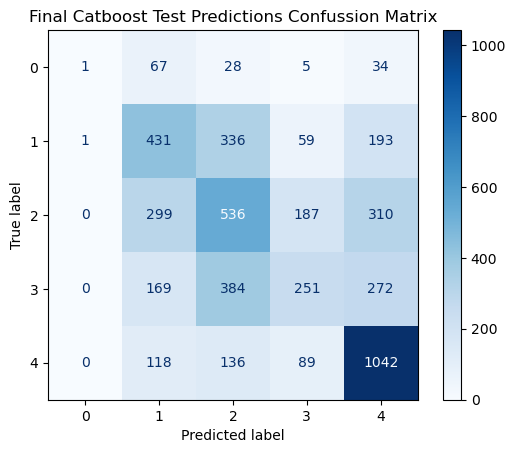

In [16]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    test_preds_catboost, 
    cmap='Blues', 
)

plt.title("Final Catboost Test Predictions Confussion Matrix")
plt.savefig('../images/4_part/Final_Catboost_Test_Predictions_Confussion_Matrix.png', bbox_inches='tight') 
plt.show()


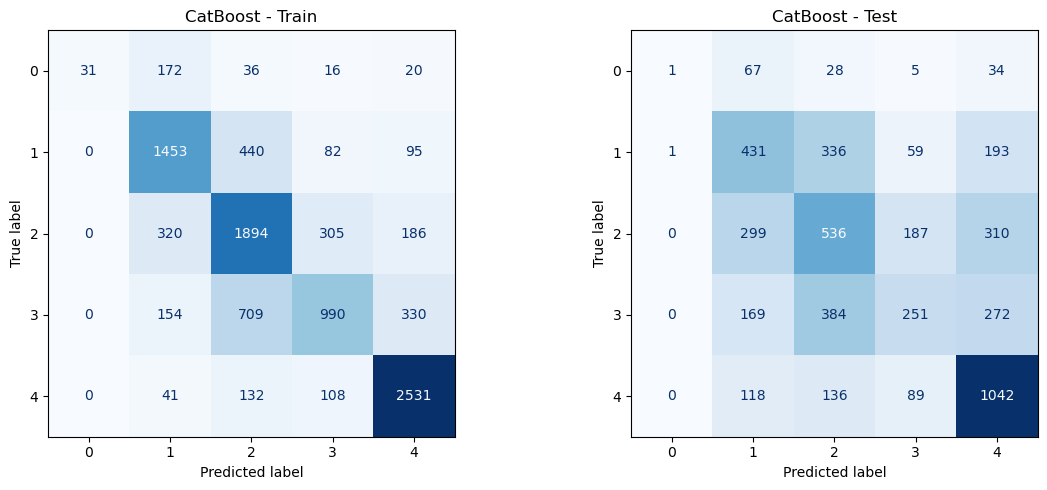

In [17]:
# Confusion matrix train vs test (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    train_preds_catboost,
    cmap='Blues',
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("CatBoost - Train")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds_catboost,
    cmap='Blues',
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("CatBoost - Test")

plt.tight_layout()
plt.show()

#### LightGBM

In [18]:
# Model training
lgbm_params = lgbm_study.best_params.copy()
print(lgbm_params)

# Remove preprocessor-specific param to avoid argument errors
loe_sigma_lgbm = lgbm_params.pop("looe_sigma", None)

lgbm = LGBMClassifier(
    **lgbm_params,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

preprocessorLOEEALL.set_params(LOOE__sigma=loe_sigma_lgbm)

pipe_lgbm = imb_make_pipeline(clone(preprocessorLOEEALL), RandomOverSampler(random_state=42), lgbm)

pipe_lgbm.fit(X_train, y_train)

# Predictions
train_preds_lgbm = pipe_lgbm.predict(X_train)
test_preds_lgbm = pipe_lgbm.predict(X_test)

# Train Score
train_f1_lgbm = f1_score(y_train, train_preds_lgbm, average='macro')
train_qwk_lgbm = cohen_kappa_score(y_train, train_preds_lgbm, weights='quadratic')

# Final Test Score
test_f1_lgbm = f1_score(y_test, test_preds_lgbm, average='macro')
test_qwk_lgbm = cohen_kappa_score(y_test, test_preds_lgbm, weights='quadratic')

print(f"FINAL RESULTS WITH LIGHTGBM MODEL:")
print(f"TRAIN -> F1: {round(train_f1_lgbm, 4)} | QWK: {round(train_qwk_lgbm, 4)}")
print(f"TEST  -> F1: {round(test_f1_lgbm, 4)}  | QWK: {round(test_qwk_lgbm, 4)}")

{'looe_sigma': 0.017274353532403468, 'n_estimators': 431, 'max_depth': 14, 'learning_rate': 0.021117244921237944, 'num_leaves': 49, 'min_child_samples': 8, 'subsample': 0.7392171099865767, 'colsample_bytree': 0.9999202226086774}


c:\Users\iker\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


FINAL RESULTS WITH LIGHTGBM MODEL:
TRAIN -> F1: 0.5941 | QWK: 0.6482
TEST  -> F1: 0.3551  | QWK: 0.3985


c:\Users\iker\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


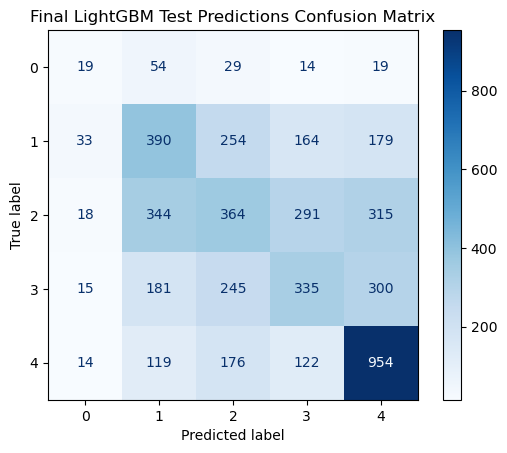

In [19]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    test_preds_lgbm, 
    cmap='Blues', 
)

plt.title("Final LightGBM Test Predictions Confusion Matrix")

plt.savefig('../images/4_part/Final_LightGBM_Test_Predictions_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

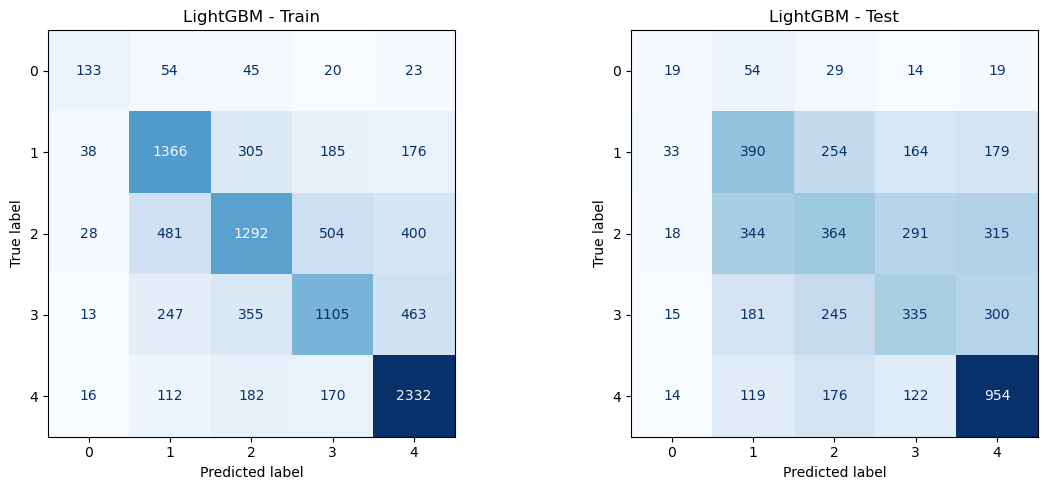

In [20]:
# Confusion matrix train vs test (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    train_preds_lgbm,
    cmap='Blues',
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("LightGBM - Train")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds_lgbm,
    cmap='Blues',
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("LightGBM - Test")

plt.tight_layout()
plt.show()

#### XGBoost

In [21]:
# Model training
xgb_params = xgb_study.best_params.copy()
print(xgb_params)

# Remove preprocessor-specific param to avoid argument errors
loe_sigma_xgb = xgb_params.pop("looe_sigma", None)

xgboost = xgb.XGBClassifier(
    **xgb_params,    
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

preprocessorLOEEALL.set_params(LOOE__sigma=loe_sigma_xgb)

pipe_xgboost = imb_make_pipeline(clone(preprocessorLOEEALL), RandomOverSampler(random_state=42), xgboost)

pipe_xgboost.fit(X_train, y_train)

# Predictions
train_preds_xgboost = pipe_xgboost.predict(X_train)
test_preds_xgboost = pipe_xgboost.predict(X_test)

# Train Score
train_f1_xgboost = f1_score(y_train, train_preds_xgboost, average='macro')
train_qwk_xgboost = cohen_kappa_score(y_train, train_preds_xgboost, weights='quadratic')

# Final Test Score
test_f1_xgboost = f1_score(y_test, test_preds_xgboost, average='macro')
test_qwk_xgboost = cohen_kappa_score(y_test, test_preds_xgboost, weights='quadratic')

print(f"FINAL RESULTS WITH XGBOOST MODEL:")
print(f"TRAIN -> F1: {round(train_f1_xgboost, 4)} | QWK: {round(train_qwk_xgboost, 4)}")
print(f"TEST  -> F1: {round(test_f1_xgboost, 4)}  | QWK: {round(test_qwk_xgboost, 4)}")

{'looe_sigma': 0.010773764065091765, 'n_estimators': 552, 'max_depth': 10, 'learning_rate': 0.01294031155889707, 'subsample': 0.6459278279430541, 'colsample_bytree': 0.6169935895547909, 'min_child_weight': 1}
FINAL RESULTS WITH XGBOOST MODEL:
TRAIN -> F1: 0.6409 | QWK: 0.6762
TEST  -> F1: 0.3717  | QWK: 0.4194


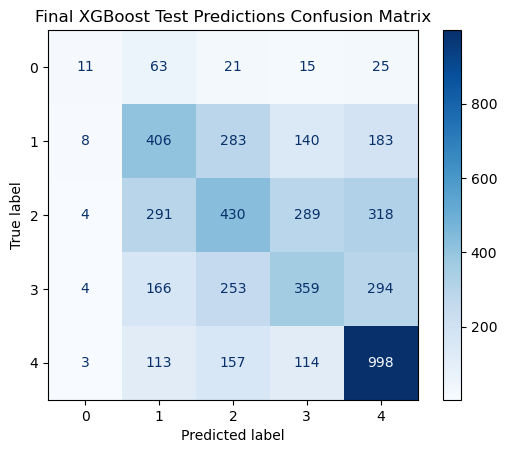

In [22]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    test_preds_xgboost, 
    cmap='Blues', 
)

plt.title("Final XGBoost Test Predictions Confusion Matrix")
plt.savefig('../images/4_part/Final_XGBoost_Test_Predictions_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

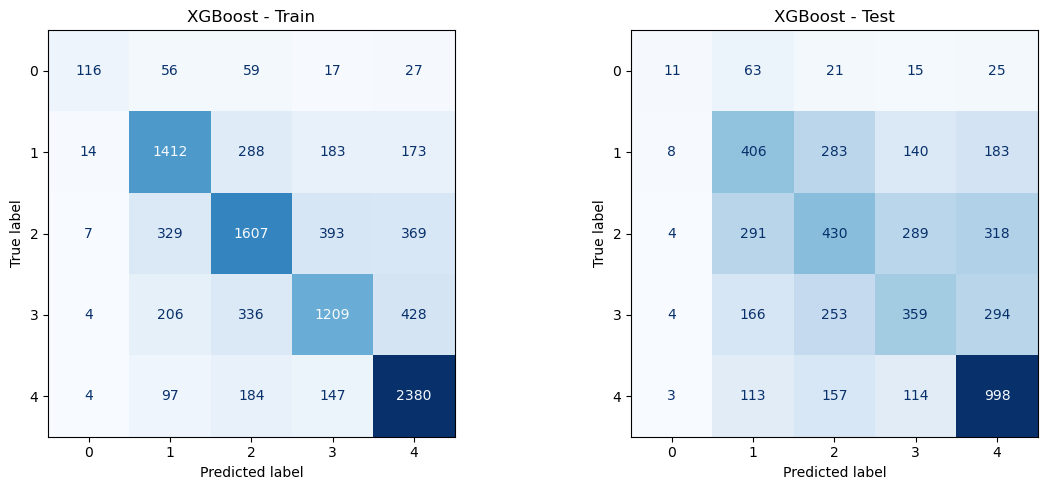

In [23]:
# Confusion matrix train vs test (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    train_preds_xgboost,
    cmap='Blues',
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("XGBoost - Train")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds_xgboost,
    cmap='Blues',
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("XGBoost - Test")

plt.tight_layout()
plt.show()

#### Gradient Boosting

In [24]:
# Model training
gbm_params = gbm_study.best_params.copy()
print(gbm_params)

# Remove preprocessor-specific param to avoid argument errors
loe_sigma_gbm = gbm_params.pop("looe_sigma", None)

gb = GradientBoostingClassifier(
    **gbm_params,
    random_state=42
    )

preprocessorLOEEALL.set_params(LOOE__sigma=loe_sigma_gbm)

pipe_gb = imb_make_pipeline(clone(preprocessorLOEEALL), gb)

pipe_gb.fit(X_train, y_train)

# Predictions
train_preds_gb = pipe_gb.predict(X_train)
test_preds_gb = pipe_gb.predict(X_test)

# Train Score
train_f1_gb = f1_score(y_train, train_preds_gb, average='macro')
train_qwk_gb = cohen_kappa_score(y_train, train_preds_gb, weights='quadratic')

# Final Test Score
test_f1_gb = f1_score(y_test, test_preds_gb, average='macro')
test_qwk_gb = cohen_kappa_score(y_test, test_preds_gb, weights='quadratic')

print(f"FINAL RESULTS WITH GRADIENT BOOSTING MODEL:")
print(f"TRAIN -> F1: {round(train_f1_gb, 4)} | QWK: {round(train_qwk_gb, 4)}")
print(f"TEST  -> F1: {round(test_f1_gb, 4)}  | QWK: {round(test_qwk_gb, 4)}")

{'looe_sigma': 0.021372534159264083, 'n_estimators': 138, 'max_depth': 3, 'learning_rate': 0.0788176779144456, 'min_samples_leaf': 32, 'subsample': 0.9993202620699826, 'max_features': 0.7944324429031259}
FINAL RESULTS WITH GRADIENT BOOSTING MODEL:
TRAIN -> F1: 0.4192 | QWK: 0.5481
TEST  -> F1: 0.3204  | QWK: 0.3937


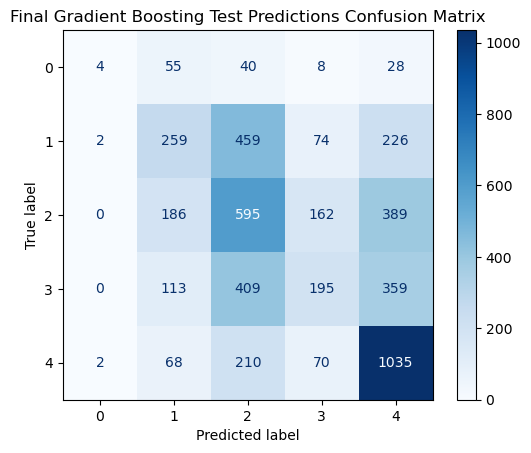

In [25]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    test_preds_gb, 
    cmap='Blues', 
)

plt.title("Final Gradient Boosting Test Predictions Confusion Matrix")
plt.savefig('../images/4_part/Final_Gradient_Boosting_Test_Predictions_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

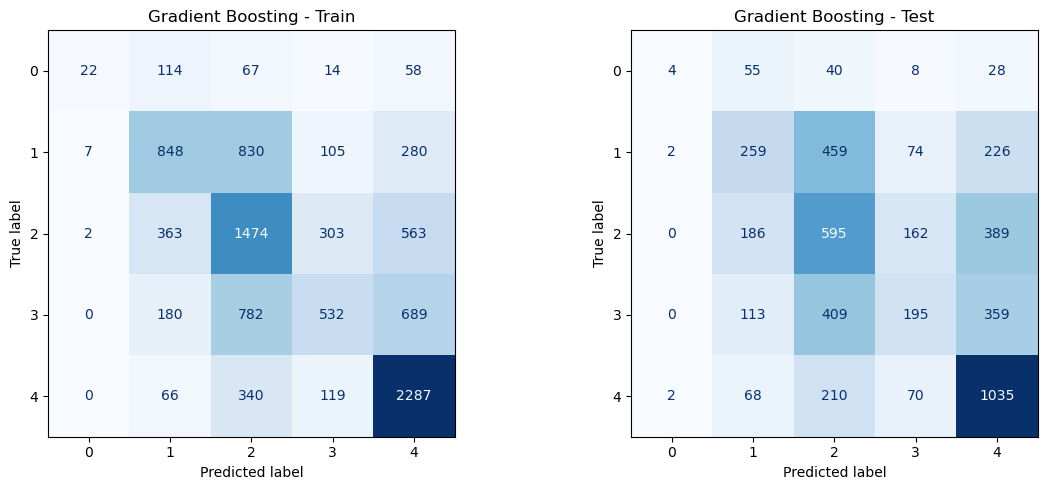

In [26]:
# Confusion matrix train vs test (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    train_preds_gb,
    cmap='Blues',
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Gradient Boosting - Train")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds_gb,
    cmap='Blues',
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Gradient Boosting - Test")

plt.tight_layout()
plt.show()

#### Random Forest

In [27]:
# Model training
rf_params = rf_study.best_params.copy()
print(rf_params)

# Remove preprocessor-specific param to avoid argument errors
loe_sigma_rf = rf_params.pop("looe_sigma", None)

rf = RandomForestClassifier(
    **rf_params,    
    class_weight="balanced",    
    random_state=42,
    n_jobs=-1
)
preprocessorLOEEALL.set_params(LOOE__sigma=loe_sigma_rf)

pipe_rf = imb_make_pipeline(clone(preprocessorLOEEALL), rf)

pipe_rf.fit(X_train, y_train)

# Predictions
train_preds_rf = pipe_rf.predict(X_train)
test_preds_rf = pipe_rf.predict(X_test)

# Train Score
train_f1_rf = f1_score(y_train, train_preds_rf, average='macro')
train_qwk_rf = cohen_kappa_score(y_train, train_preds_rf, weights='quadratic')

# Final Test Score
test_f1_rf = f1_score(y_test, test_preds_rf, average='macro')
test_qwk_rf = cohen_kappa_score(y_test, test_preds_rf, weights='quadratic')

print(f"FINAL RESULTS WITH RANDOM FOREST MODEL:")
print(f"TRAIN -> F1: {round(train_f1_rf, 4)} | QWK: {round(train_qwk_rf, 4)}")
print(f"TEST  -> F1: {round(test_f1_rf, 4)}  | QWK: {round(test_qwk_rf, 4)}")

{'looe_sigma': 0.013264638423263085, 'n_estimators': 505, 'max_depth': 60, 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
FINAL RESULTS WITH RANDOM FOREST MODEL:
TRAIN -> F1: 0.6446 | QWK: 0.6683
TEST  -> F1: 0.3499  | QWK: 0.4021


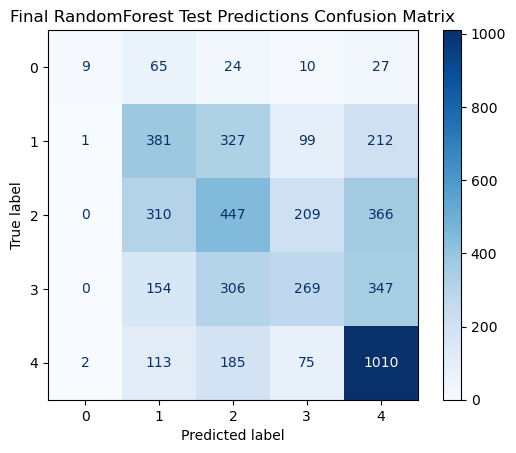

In [28]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    test_preds_rf, 
    cmap='Blues', 
)

plt.title("Final RandomForest Test Predictions Confusion Matrix")
plt.savefig('../images/4_part/Final_RandomForest_Test_Predictions_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

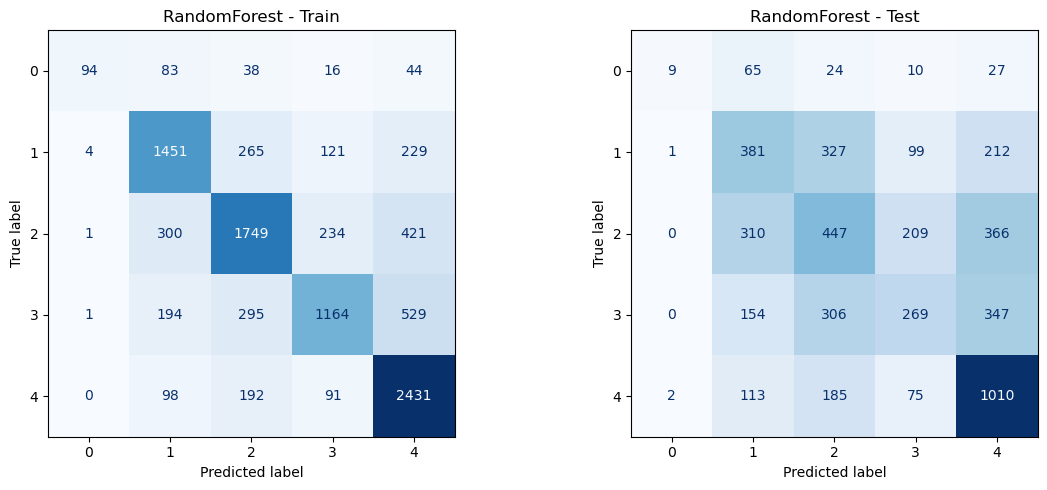

In [29]:
# Confusion matrix train vs test (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    train_preds_rf,
    cmap='Blues',
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("RandomForest - Train")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds_rf,
    cmap='Blues',
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("RandomForest - Test")

plt.tight_layout()
plt.show()

#### Final confusion matrix

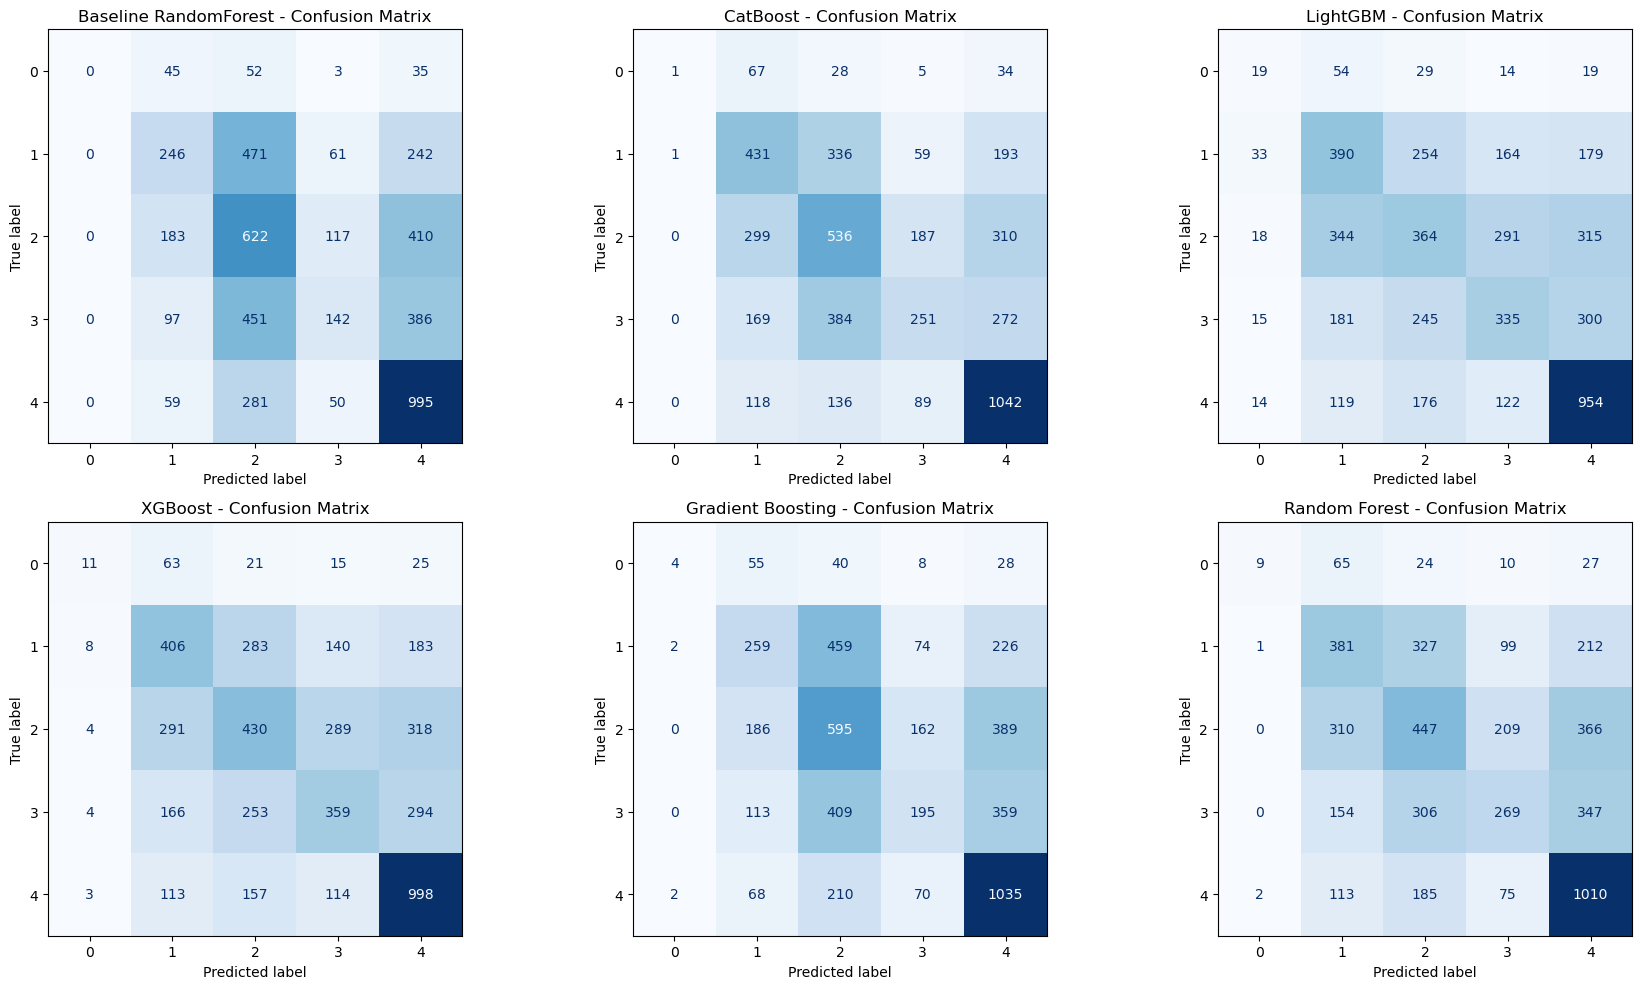

In [30]:
# Confusion matrices for baseline and all individual models

model_predictions = [
    ("Baseline RandomForest", test_preds),
    ("CatBoost", test_preds_catboost),
    ("LightGBM", test_preds_lgbm),
    ("XGBoost", test_preds_xgboost),
    ("Gradient Boosting", test_preds_gb),
    ("Random Forest", test_preds_rf),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, (model_name, preds) in enumerate(model_predictions):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        preds,
        cmap='Blues',
        ax=axes[i],
        colorbar=False
    )
    axes[i].set_title(f"{model_name} - Confusion Matrix")

plt.tight_layout()
plt.savefig("../images/4_part/Final_Test_Confusion_Matrices_All_Models_and_Baseline.png", bbox_inches='tight')
plt.show()

#### CatBoost (balanced) **PRUEBA**

In [31]:
# Model training
catboost_params = cat_study.best_params.copy()
print(catboost_params)

# Remove preprocessor-specific param to avoid argument errors
loe_sigma_cat = catboost_params.pop("looe_sigma", None)

catboost = CatBoostClassifier(
    random_state=42,
    verbose=0, 
    allow_writing_files=False, 
    cat_features=categorical_cols,
    auto_class_weights='Balanced'
)

preprocessorLOEEALL.set_params(LOOE__sigma=loe_sigma_cat)


pipe_catboost = imb_make_pipeline(catboost)

pipe_catboost.fit(X_train, y_train)

# Predictions
train_preds_catboost = pipe_catboost.predict(X_train)
test_preds_catboost = pipe_catboost.predict(X_test)

# Train Score
train_f1_catboost = f1_score(y_train, train_preds_catboost, average='macro')
train_qwk_catboost = cohen_kappa_score(y_train, train_preds_catboost, weights='quadratic')

# Final Test Score
test_f1_catboost = f1_score(y_test, test_preds_catboost, average='macro')
test_qwk_catboost = cohen_kappa_score(y_test, test_preds_catboost, weights='quadratic')

print(f"FINAL RESULTS WITH CATBOOST MODEL:")
print(f"TRAIN -> F1: {round(train_f1_catboost, 4)} | QWK: {round(train_qwk_catboost, 4)}")
print(f"TEST  -> F1: {round(test_f1_catboost, 4)}  | QWK: {round(test_qwk_catboost, 4)}")

{'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 3.0}
FINAL RESULTS WITH CATBOOST MODEL:
TRAIN -> F1: 0.7532 | QWK: 0.7971
TEST  -> F1: 0.3845  | QWK: 0.4412


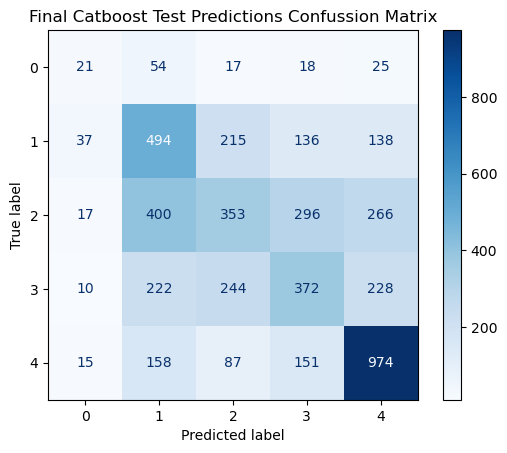

In [32]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    test_preds_catboost, 
    cmap='Blues', 
)

plt.title("Final Catboost Test Predictions Confussion Matrix")
plt.savefig('../images/4_part/Final_Balanced_Catboost_Test_Predictions_Confussion_Matrix.png', bbox_inches='tight') 
plt.show()

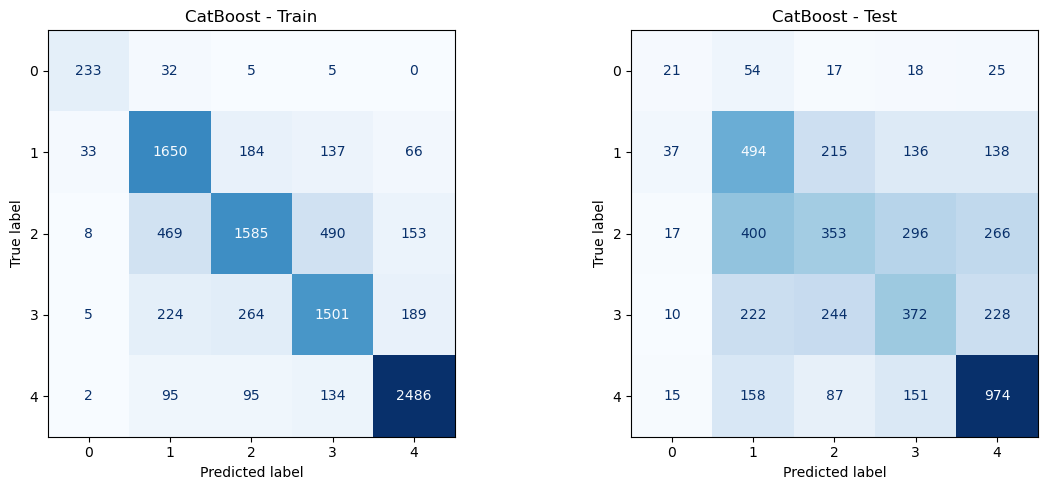

In [33]:
# Confusion matrix train vs test (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    train_preds_catboost,
    cmap='Blues',
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("CatBoost - Train")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds_catboost,
    cmap='Blues',
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("CatBoost - Test")

plt.tight_layout()
plt.show()

### **Group models**

#### Stacking Classifier


In [34]:
base_estimators = [
    ('rf', pipe_rf),
    ('lgbm', pipe_lgbm),
    ('cat', pipe_catboost),
    ('xgb', pipe_xgboost),
    ('gbm', pipe_gb)
]

final_model = LogisticRegression(max_iter=1000, C=0.1, random_state=42)

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=final_model,
    cv=5,
    n_jobs=-1,
    passthrough=False
)

stacking_clf.fit(X_train, y_train)

# Predictions
train_preds_stacking = stacking_clf.predict(X_train)
test_preds_stacking = stacking_clf.predict(X_test)

# Train Score
train_f1_stacking = f1_score(y_train, train_preds_stacking, average='macro')
train_qwk_stacking = cohen_kappa_score(y_train, train_preds_stacking, weights='quadratic')

# Final Test Score
test_f1_stacking = f1_score(y_test, test_preds_stacking, average='macro')
test_qwk_stacking = cohen_kappa_score(y_test, test_preds_stacking, weights='quadratic')

print(f"FINAL RESULTS WITH STACKING CLASSIFIER:")
print(f"TRAIN -> F1: {round(train_f1_stacking, 4)} | QWK: {round(train_qwk_stacking, 4)}")
print(f"TEST  -> F1: {round(test_f1_stacking, 4)}  | QWK: {round(test_qwk_stacking, 4)}")

c:\Users\iker\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\iker\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


FINAL RESULTS WITH STACKING CLASSIFIER:
TRAIN -> F1: 0.5613 | QWK: 0.7495
TEST  -> F1: 0.3461  | QWK: 0.4449


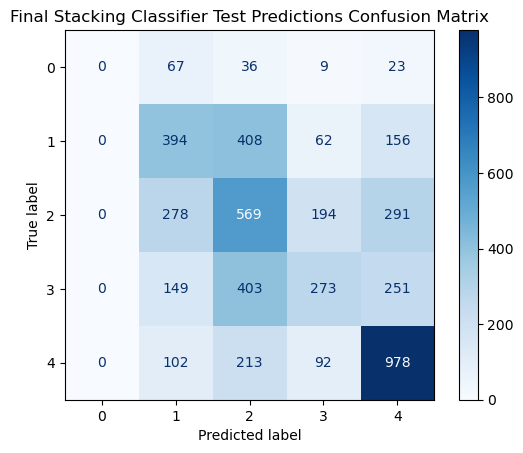

In [35]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds_stacking,
    cmap='Blues',
)

plt.title("Final Stacking Classifier Test Predictions Confusion Matrix")
plt.savefig('../images/4_part/Final_Stacking_Classifier_Test_Predictions_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

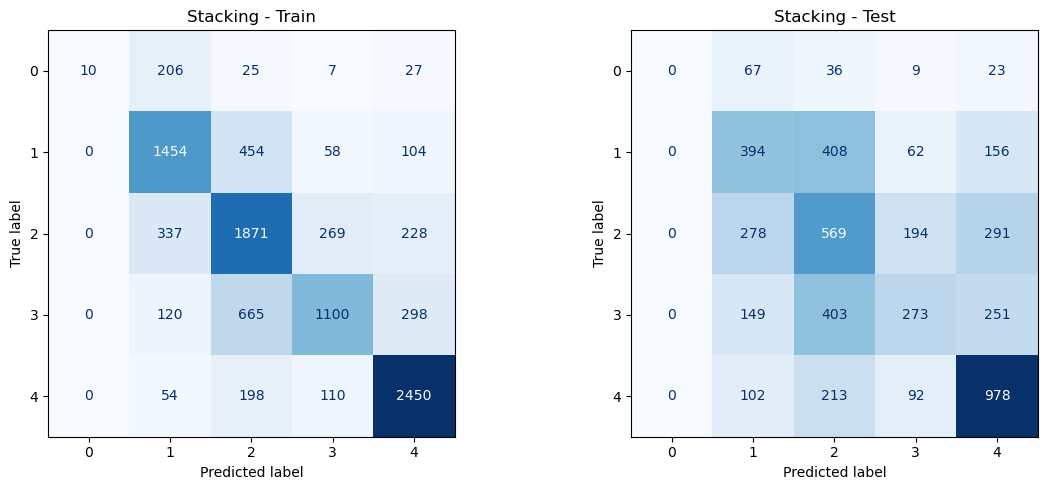

In [36]:
# Confusion matrix train vs test (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    train_preds_stacking,
    cmap='Blues',
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Stacking - Train")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds_stacking,
    cmap='Blues',
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Stacking - Test")

plt.tight_layout()
plt.show()

#### Voting Classifier

In [37]:
voting_clf = VotingClassifier(
    estimators=[
        ('rf', pipe_rf),
        ('lgbm', pipe_lgbm),
        ('cat', pipe_catboost),
        ('xgb', pipe_xgboost),
        ('gbm', pipe_gb)
    ],
    voting='soft',
    weights=[1, 2, 5, 2, 1]
)

voting_clf.fit(X_train, y_train)

# Predictions
train_preds_voting = voting_clf.predict(X_train)
test_preds_voting = voting_clf.predict(X_test)

# Train Score
train_f1_voting = f1_score(y_train, train_preds_voting, average='macro')
train_qwk_voting = cohen_kappa_score(y_train, train_preds_voting, weights='quadratic')

# Final Test Score
test_f1_voting = f1_score(y_test, test_preds_voting, average='macro')
test_qwk_voting = cohen_kappa_score(y_test, test_preds_voting, weights='quadratic')

print(f"FINAL RESULTS WITH VOTING CLASSIFIER:")
print(f"TRAIN -> F1: {round(train_f1_voting, 4)} | QWK: {round(train_qwk_voting, 4)}")
print(f"TEST  -> F1: {round(test_f1_voting, 4)}  | QWK: {round(test_qwk_voting, 4)}")

c:\Users\iker\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\iker\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


FINAL RESULTS WITH VOTING CLASSIFIER:
TRAIN -> F1: 0.7385 | QWK: 0.7617
TEST  -> F1: 0.3798  | QWK: 0.4337


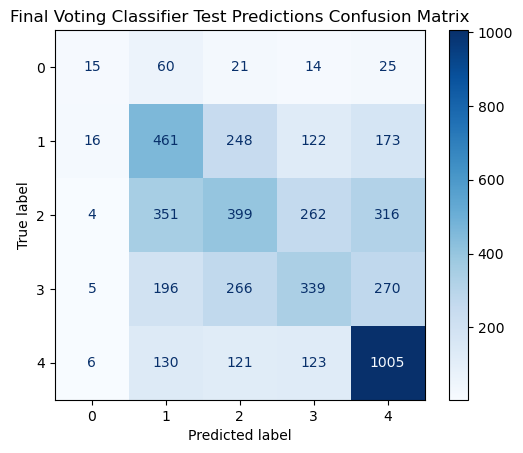

In [38]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds_voting,
    cmap='Blues',
)

plt.title("Final Voting Classifier Test Predictions Confusion Matrix")
plt.savefig('../images/4_part/Final_Voting_Classifier_Test_Predictions_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

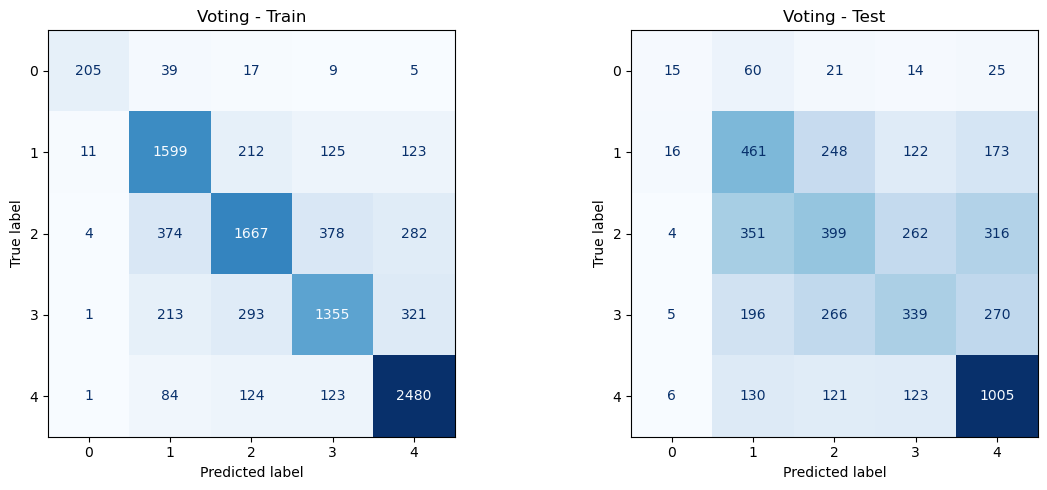

In [39]:
# Confusion matrix train vs test (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    train_preds_voting,
    cmap='Blues',
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Voting - Train")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds_voting,
    cmap='Blues',
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Voting - Test")

plt.tight_layout()
plt.show()